In [3]:
import sys
sys.path.append('../../../../src')
import pickle
from energiapy.plot import plot_results, plot_scenario, plot_location
from matplotlib import pyplot as plt
from matplotlib import rc

In [4]:
with open(f'control/ncl_ControlResults_Backlog.pkl', 'rb') as file:
    ncl_load_results = pickle.load(file)

In [5]:
with open(f'control/cl_ControlResults_Backlog.pkl', 'rb') as file:
    cl_load_results = pickle.load(file)

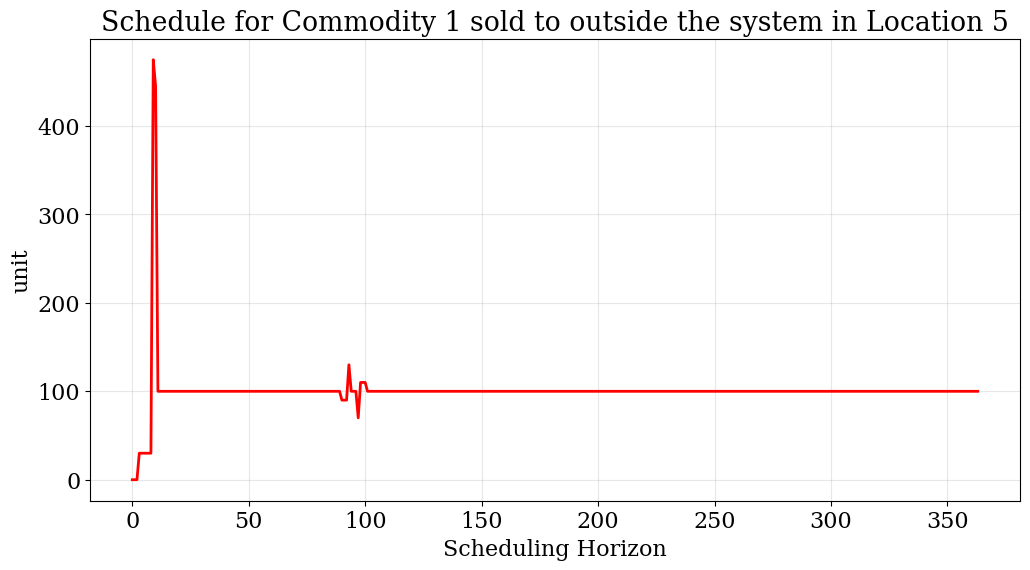

In [6]:
plot_results.schedule(results=ncl_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

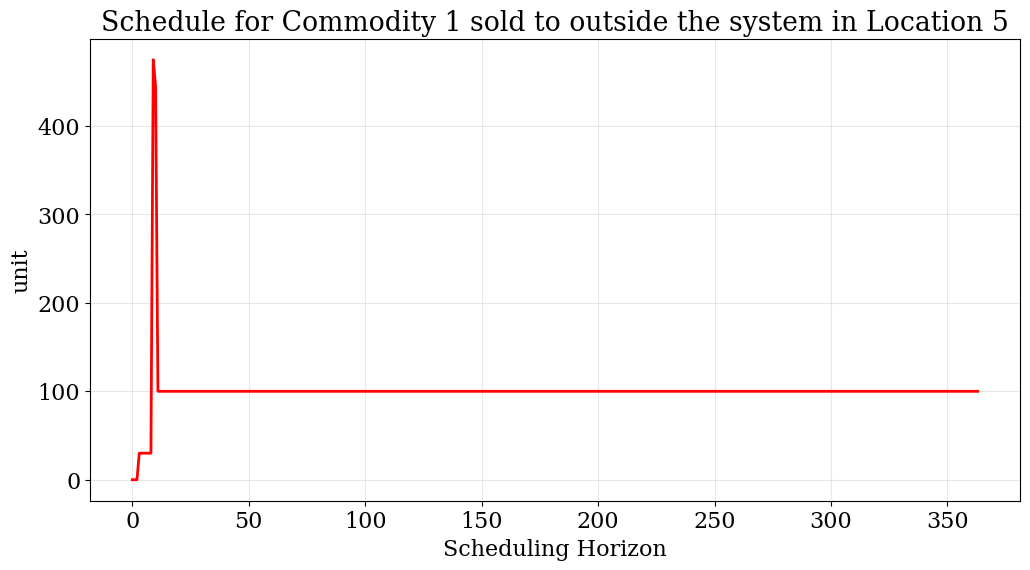

In [7]:
plot_results.schedule(results=cl_load_results, y_axis='S', component='com1_sold', location='loc5', color='red')

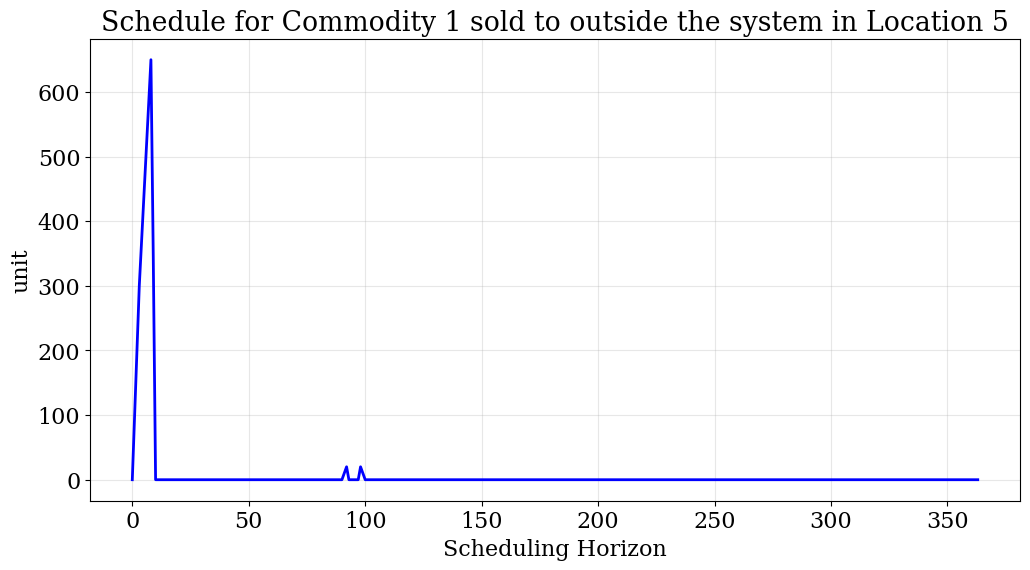

In [8]:
plot_results.schedule(results=ncl_load_results, y_axis='Demand_backlog', component='com1_sold', location='loc5')

In [9]:
ncl_load_results.output.keys()

dict_keys(['termination', 'LB', 'UB', 'n_cons', 'n_vars', 'n_binvars', 'n_intvars', 'n_convars', 'n_nonzero', 'P', 'B', 'C', 'S', 'R', 'Inv', 'P_m', 'P_material_m', 'Cap_P', 'Cap_S', 'P_location', 'P_location_material_m', 'S_location', 'R_location', 'C_location', 'B_location', 'P_network', 'S_network', 'R_network', 'C_network', 'B_network', 'Trans_cost_network', 'Fopex_process', 'Vopex_process', 'Capex_process', 'Incidental_process', 'Capex_storage', 'Fopex_location', 'Vopex_location', 'Capex_location', 'Incidental_location', 'Fopex_network', 'Vopex_network', 'Capex_network', 'Incidental_network', 'Inv_network', 'Cost', 'Inv_cost', 'Inv_cost_location', 'Inv_cost_network', 'X_F', 'Cap_F', 'Exp_R', 'Exp_F', 'Exp_F_network', 'Exp', 'Capex_transport', 'Vopex_transport', 'Fopex_transport', 'Capex_transport_network', 'Vopex_transport_network', 'Fopex_transport_network', 'X_P', 'X_S', 'Demand_penalty', 'Demand_penalty_location', 'Demand_penalty_network', 'Demand_penalty_cost', 'Demand_penalty

In [10]:
a = ncl_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + ncl_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
# a = ncl_load_results.output['objective']

In [11]:
b = cl_load_results.output['Demand_backlog_cost_network']['com1_sold',0] + cl_load_results.output['Demand_penalty_cost_network']['com1_sold',0]
# b = cl_load_results.output['objective']

In [12]:
(b-a)/a

-0.031746031746031744

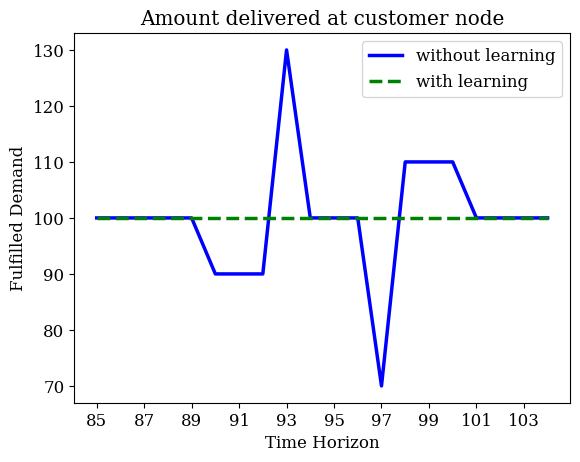

In [13]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=85
end = start+20

ax.plot(range(start, end), list(value for key, value in ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='without learning', color='blue', linestyle='-', linewidth='2.5')

ax.plot(range(start, end), list(value for key, value in cl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='with learning', color='green', linestyle='--', linewidth='2.5')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Fulfilled Demand')
ax.set_title('Amount delivered at customer node')
ax.legend()
ax.plot(linewidth=0.5)
ax.set_xticks(range(start, end, 2))
# plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'cl_ncl_compare', dpi = 300)
# Show the plot
plt.show()

ValueError: x and y must have same first dimension, but have shapes (279,) and (364,)

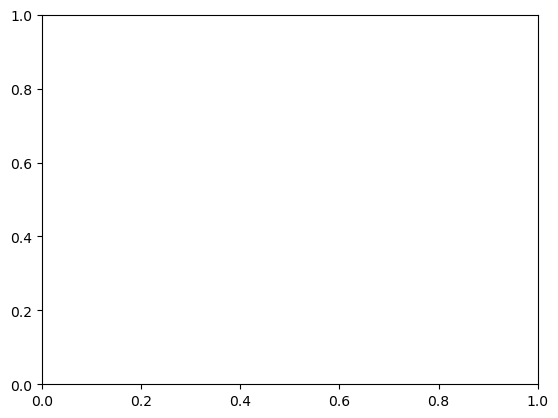

In [17]:
x = list(range(start, len(list(value for key, value in ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold'))))
y = list(value for key, value in ncl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')
# y2 = [556280.48, 383540.86, 373214.82, 645751.8, 437765.47]
# Plotting
plt.plot(x, y, marker='', label='Location 5')  # 'o' adds circular markers at data points
# plt.plot(x, y2, marker='x', label='approx_obj')
plt.title('Delivery under demand variability')
plt.xlabel('Time Horizon')
plt.ylabel('Delivery Level')
plt.grid(True)
plt.legend()
plt.savefig(fname = 'MPC_demand', dpi = 300)
plt.show()

In [ ]:
x = list(range(start, len(list(value for key, value in ncl_load_results.output['Demand_penalty'].items() if key[0]=='loc5' and key[1]=='com1_sold'))))
y = list(value for key, value in ncl_load_results.output['Demand_penalty'].items() if key[0]=='loc5' and key[1]=='com1_sold')
# y2 = [556280.48, 383540.86, 373214.82, 645751.8, 437765.47]
# Plotting
plt.plot(x, y, marker='', label='Location 5')  # 'o' adds circular markers at data points
# plt.plot(x, y2, marker='x', label='approx_obj')
plt.title('Unmet demand under demand variability')
plt.xlabel('Time Horizon')
plt.ylabel('Unmet Demand Level')
plt.grid(True)
plt.legend()
plt.savefig(fname = 'MPC_demand_penalty', dpi = 300)
plt.show()

In [ ]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset

key1 = 0
key2 = 3
start=0

ax.plot(range(start, len(list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1'))), list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1'), label='Location 1', color='red', linestyle='-.')

ax.plot(range(start, len(list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1'))), list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1'), label='Location 6', color='green', linestyle='-')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Procurement Level')
ax.set_title('Procurement levels under demand variability')
ax.legend()
ax.plot(linewidth=0.5)
plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'MPC_supply', dpi = 300)
# Show the plot
plt.show()

In [ ]:
ncl_load_results.output['Cap_P']['loc6','com1_loc6_send', 0]

In [ ]:
ncl_load_results.output['Cap_F']['loc6','loc4','truck64', 0]

In [ ]:
x = list(range(start, len(list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1'))))
y = list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc1' and key[1]=='procure com1')
y2 = list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1')
# Plotting
plt.plot(x, y, marker='', label='Location 1')  # 'o' adds circular markers at data points
plt.plot(x, y2, marker='', label='Location 6', linestyle='--')
plt.title('Procurement levels under demand variability')
plt.xlabel('Time Horizon')
plt.ylabel('Procurement')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
ncl_load_results.output['Capex_network']

In [ ]:
ncl_load_results.output['Vopex_network']

In [ ]:
ncl_load_results.output['Demand_penalty_network']

In [ ]:
ncl_load_results.output['Demand_penalty']

In [ ]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

# Plot data from the first dataset
start=0

a=1
b=2
ax.plot(range(start, len(list(value for key, value in ncl_load_results.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out'))), list(value for key, value in ncl_load_results.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out'), label=f'Truck {a}{b}', color='red', linestyle='-.')

a=6
b=4
ax.plot(range(start, len(list(value for key, value in ncl_load_results.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out'))), list(value for key, value in ncl_load_results.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out'), label=f'Truck {a}{b}', color='green', linestyle='-')

a=4
b=5
ax.plot(range(start, len(list(value for key, value in ncl_load_results.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out'))), list(value for key, value in ncl_load_results.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out'), label=f'Truck {a}{b}', color='blue', linestyle='-')

a=4
b=7
ax.plot(range(start, len(list(value for key, value in ncl_load_results.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out'))), list(value for key, value in ncl_load_results.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'truck{a}{b}' and key[3]==f'com1_loc{a}_out'), label=f'Truck {a}{b}', color='red', linestyle='--')

a=1
b=5
ax.plot(range(start, len(list(value for key, value in ncl_load_results.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'plane{a}{b}' and key[3]==f'com1_loc{a}_out'))), list(value for key, value in ncl_load_results.output['Exp'].items() if key[0]==f'loc{a}' and key[1]==f'loc{b}' and key[2]==f'plane{a}{b}' and key[3]==f'com1_loc{a}_out'), label=f'Plane {a}{b}', color='red', linestyle='--')

# ax.plot(range(start, len(list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1'))), list(value for key, value in ncl_load_results.output['P'].items() if key[0]=='loc6' and key[1]=='procure com1'), label='Location 6', color='green', linestyle='-')

# Customize the plot
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Transport Level')
ax.set_title('Product transport under demand variability')
ax.legend()
ax.plot(linewidth=0.5)
plt.grid(alpha=0.6)
plt.rcdefaults()
plt.savefig(fname = 'MPC_logistics', dpi = 300)
# Show the plot
plt.show()

In [ ]:
ncl_load_results.output['objective']

In [ ]:
ncl_load_results.output.keys()